In [ ]:
# ── CELL 1: Setup ──────────────────────────────
!pip install matplotlib-venn -q

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print("✅ All dependencies ready")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


✅ All dependencies ready


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


# ── CELL 2: Imports and Path Setup ──────────────────────────────
import os
import re
import string
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

SMRITI_PATH = "/content/drive/MyDrive/NLP/Political/data/smriti_irani"
DEREK_PATH = "/content/drive/MyDrive/NLP/Political/data/derek_obrien"
OUTPUT_PATH = "/content/drive/MyDrive/NLP/Political/data/outputs"

os.makedirs(OUTPUT_PATH, exist_ok=True)
print("✅ Paths ready")

✅ Paths ready


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
import os

def load_documents(folder_path):

    documents = []
    filenames = []

    for file in sorted(os.listdir(folder_path)):

        if file.endswith(".txt"):

            path = os.path.join(folder_path, file)

            with open(path, "r", encoding="utf-8") as f:

                documents.append(f.read())
                filenames.append(file)

    return documents, filenames


smriti_docs, smriti_files = load_documents(SMRITI_PATH)
derek_docs, derek_files = load_documents(DEREK_PATH)

print("Smriti transcripts:", len(smriti_docs))
print("Derek transcripts:", len(derek_docs))

Smriti transcripts: 8
Derek transcripts: 8


In [ ]:
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# ── CELL 3: Define Cleaning Pipeline ──────────────────────────────

PROCEDURAL_PHRASES = [
    "honourable speaker", "through you sir", "question hour",
    "zero hour", "point of order", "treasury benches",
    "presiding officer", "hon member", "hon minister",
    "speaker sir", "madam speaker", "the chair"
]

CUSTOM_STOPWORDS = {
    "government", "parliament", "country", "state", "party",
    "people", "citizens", "minister", "members", "india",
    "said", "also", "would", "could", "one", "like", "get",
    "will", "say", "house", "member", "hon", "sir"
}

NLTK_STOPWORDS = set(stopwords.words('english'))
ALL_STOPWORDS  = NLTK_STOPWORDS.union(CUSTOM_STOPWORDS)


def extract_speech_text(raw):
    """Extract everything after 'Speech Text:' label."""
    marker = "Speech Text:"
    idx = raw.find(marker)
    if idx != -1:
        return raw[idx + len(marker):].strip()
    return raw.strip()   # fallback: use full content


def clean_text(text):
    # lowercase
    text = text.lower()

    # remove procedural phrases
    for phrase in PROCEDURAL_PHRASES:
        text = text.replace(phrase, " ")

    # remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # remove bracketed stage directions e.g. [Interruptions]
    text = re.sub(r'\[.*?\]', ' ', text)
    text = re.sub(r'\(.*?\)', ' ', text)

    # remove numbers
    text = re.sub(r'\d+', ' ', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # tokenize
    tokens = word_tokenize(text)

    # filter tokens
    tokens = [
        t for t in tokens
        if t.isalpha()           # alphabetic only
        and len(t) >= 3          # min length 3
        and t not in ALL_STOPWORDS
    ]

    return " ".join(tokens)


print("✅ Cleaning functions defined")

✅ Cleaning functions defined


In [ ]:
import pandas as pd
import os
import re

# ── CELL 4: Load and Parse Transcripts ──────────────────────────────

def load_and_parse(folder_path, leader_name):
    records = []

    for filename in sorted(os.listdir(folder_path)):
        if not filename.endswith(".txt"):
            continue

        filepath = os.path.join(folder_path, filename)
        with open(filepath, "r", encoding="utf-8") as f:
            raw = f.read()

        # Extract metadata fields
        def extract_field(label, text):
            pattern = rf"{label}:(.*?)(?=\n[A-Z][a-z ]+:|$)"
            match = re.search(pattern, text, re.DOTALL)
            return match.group(1).strip() if match else ""

        title   = extract_field("Speech Title", raw)
        date    = extract_field("Date", raw)
        source  = extract_field("Source", raw)
        context = extract_field("Speaker Context", raw)

        raw_speech  = extract_speech_text(raw)
        words_before = len(raw_speech.split())

        cleaned     = clean_text(raw_speech)
        words_after  = len(cleaned.split())

        records.append({
            "leader"      : leader_name,
            "filename"    : filename,
            "title"       : title,
            "date"        : date,
            "source"      : source,
            "context"     : context,
            "raw_text"    : raw_speech,
            "cleaned_text": cleaned,
            "words_before": words_before,
            "words_after" : words_after
        })

    return pd.DataFrame(records)


smriti_df = load_and_parse(SMRITI_PATH, "smriti_irani")
derek_df  = load_and_parse(DEREK_PATH,  "derek_obrien")

print("Smriti rows:", len(smriti_df))
print("Derek rows :", len(derek_df))

Smriti rows: 8
Derek rows : 8


In [ ]:
# ── CELL 5: Export CSVs ──────────────────────────────

combined_df = pd.concat([smriti_df, derek_df], ignore_index=True)

smriti_df.to_csv(  f"{OUTPUT_PATH}/smriti_irani_cleaned.csv", index=False)
derek_df.to_csv(   f"{OUTPUT_PATH}/derek_obrien_cleaned.csv", index=False)
combined_df.to_csv(f"{OUTPUT_PATH}/combined_cleaned.csv",     index=False)

print("✅ CSVs exported to", OUTPUT_PATH)
print("Combined shape:", combined_df.shape)
print("\nWord count reduction summary:")
print(combined_df[['leader','words_before','words_after']].to_string(index=False))

✅ CSVs exported to /content/drive/MyDrive/NLP/Political/data/outputs
Combined shape: (16, 10)

Word count reduction summary:
      leader  words_before  words_after
smriti_irani           681          340
smriti_irani           281          119
smriti_irani           250          141
smriti_irani           327          161
smriti_irani           478          244
smriti_irani           362          184
smriti_irani           456          237
smriti_irani           332          160
derek_obrien          1403          585
derek_obrien          1267          568
derek_obrien          1695          714
derek_obrien          1416          604
derek_obrien          1492          687
derek_obrien          1151          482
derek_obrien          1467          634
derek_obrien          2787         1174


In [ ]:
# ── CELL 3: Define Cleaning Pipeline ──────────────────────────────

PROCEDURAL_PHRASES = [
    "honourable speaker", "through you sir", "question hour",
    "zero hour", "point of order", "treasury benches",
    "presiding officer", "hon member", "hon minister",
    "speaker sir", "madam speaker", "the chair"
]

CUSTOM_STOPWORDS = {
    "government", "parliament", "country", "state", "party",
    "people", "citizens", "minister", "members", "india",
    "said", "also", "would", "could", "one", "like", "get",
    "will", "say", "house", "member", "hon", "sir"
}

NLTK_STOPWORDS = set(stopwords.words('english'))
ALL_STOPWORDS  = NLTK_STOPWORDS.union(CUSTOM_STOPWORDS)


def extract_speech_text(raw):
    """Extract everything after 'Speech Text:' label."""
    marker = "Speech Text:"
    idx = raw.find(marker)
    if idx != -1:
        return raw[idx + len(marker):].strip()
    return raw.strip()   # fallback: use full content


def clean_text(text):
    # lowercase
    text = text.lower()

    # remove procedural phrases
    for phrase in PROCEDURAL_PHRASES:
        text = text.replace(phrase, " ")

    # remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # remove bracketed stage directions e.g. [Interruptions]
    text = re.sub(r'\[.*?\]', ' ', text)
    text = re.sub(r'\(.*?\)', ' ', text)

    # remove numbers
    text = re.sub(r'\d+', ' ', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # tokenize
    tokens = word_tokenize(text)

    # filter tokens
    tokens = [
        t for t in tokens
        if t.isalpha()           # alphabetic only
        and len(t) >= 3          # min length 3
        and t not in ALL_STOPWORDS
    ]

    return " ".join(tokens)


print("✅ Cleaning functions defined")

✅ Cleaning functions defined


In [ ]:
# ── CELL 4: Load and Parse Transcripts ──────────────────────────────

def load_and_parse(folder_path, leader_name):
    records = []

    for filename in sorted(os.listdir(folder_path)):
        if not filename.endswith(".txt"):
            continue

        filepath = os.path.join(folder_path, filename)
        with open(filepath, "r", encoding="utf-8") as f:
            raw = f.read()

        # Extract metadata fields
        def extract_field(label, text):
            pattern = rf"{label}:(.*?)(?=\n[A-Z][a-z ]+:|$)"
            match = re.search(pattern, text, re.DOTALL)
            return match.group(1).strip() if match else ""

        title   = extract_field("Speech Title", raw)
        date    = extract_field("Date", raw)
        source  = extract_field("Source", raw)
        context = extract_field("Speaker Context", raw)

        raw_speech  = extract_speech_text(raw)
        words_before = len(raw_speech.split())

        cleaned     = clean_text(raw_speech)
        words_after  = len(cleaned.split())

        records.append({
            "leader"      : leader_name,
            "filename"    : filename,
            "title"       : title,
            "date"        : date,
            "source"      : source,
            "context"     : context,
            "raw_text"    : raw_speech,
            "cleaned_text": cleaned,
            "words_before": words_before,
            "words_after" : words_after
        })

    return pd.DataFrame(records)


smriti_df = load_and_parse(SMRITI_PATH, "smriti_irani")
derek_df  = load_and_parse(DEREK_PATH,  "derek_obrien")

print("Smriti rows:", len(smriti_df))
print("Derek rows :", len(derek_df))

Smriti rows: 8
Derek rows : 8


In [ ]:
# ── CELL 5: Export CSVs ──────────────────────────────

combined_df = pd.concat([smriti_df, derek_df], ignore_index=True)

smriti_df.to_csv(  f"{OUTPUT_PATH}/smriti_irani_cleaned.csv", index=False)
derek_df.to_csv(   f"{OUTPUT_PATH}/derek_obrien_cleaned.csv", index=False)
combined_df.to_csv(f"{OUTPUT_PATH}/combined_cleaned.csv",     index=False)

print("✅ CSVs exported to", OUTPUT_PATH)
print("Combined shape:", combined_df.shape)
print("\nWord count reduction summary:")
print(combined_df[['leader','words_before','words_after']].to_string(index=False))

✅ CSVs exported to /content/drive/MyDrive/NLP/Political/data/outputs
Combined shape: (16, 10)

Word count reduction summary:
      leader  words_before  words_after
smriti_irani           681          340
smriti_irani           281          119
smriti_irani           250          141
smriti_irani           327          161
smriti_irani           478          244
smriti_irani           362          184
smriti_irani           456          237
smriti_irani           332          160
derek_obrien          1403          585
derek_obrien          1267          568
derek_obrien          1695          714
derek_obrien          1416          604
derek_obrien          1492          687
derek_obrien          1151          482
derek_obrien          1467          634
derek_obrien          2787         1174


In [ ]:
# ── CELL 6: Vectorize ──────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    max_df=0.90,
    min_df=2,
    max_features=1000,
    ngram_range=(1, 1)
)

dtm  = vectorizer.fit_transform(combined_df['cleaned_text'])
vocab = vectorizer.get_feature_names_out()

print("DTM shape  :", dtm.shape)
print("Vocabulary :", len(vocab), "terms")

DTM shape  : (16, 816)
Vocabulary : 816 terms


In [ ]:
# ── CELL 7: Fit LDA ──────────────────────────────
from sklearn.decomposition import LatentDirichletAllocation

N_TOPICS     = 5
RANDOM_STATE = 42

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=50,
    learning_method='batch',
    random_state=RANDOM_STATE
)

lda.fit(dtm)

print("✅ LDA fitted")
print("Perplexity:", round(lda.perplexity(dtm), 2))

✅ LDA fitted
Perplexity: 599.46


In [ ]:
# ── CELL 8: Topic-Word Distributions ──────────────────────────────
N_TOP_WORDS = 12

print("=" * 60)
for topic_idx, topic_vec in enumerate(lda.components_):
    top_indices = topic_vec.argsort()[::-1][:N_TOP_WORDS]
    top_words   = [vocab[i] for i in top_indices]
    print(f"Topic {topic_idx+1}: {', '.join(top_words)}")
print("=" * 60)

Topic 1: women, poshan, development, child, irani, children, union, smt, centre, prime, mission, anganwadi
Topic 2: election, data, manifesto, first, commission, debate, elections, want, political, point, solution, examples
Topic 3: back, give, farmers, bill, minutes, years, states, committee, bills, four, today, bengal
Topic 4: per, cent, states, cess, opposition, last, bjp, let, dont, address, point, page
Topic 5: bill, sabha, women, want, bring, community, today, years, minutes, bengal, lok, know


In [ ]:
# ── CELL 9: Document-Topic Matrix + Speaker Profile ──────────────────────────────
import numpy as np

doc_topic_matrix = lda.transform(dtm)

topic_cols = [f'Topic {i+1}' for i in range(N_TOPICS)]

df_topics = combined_df[['leader', 'filename']].copy()
for i in range(N_TOPICS):
    df_topics[f'Topic {i+1}'] = doc_topic_matrix[:, i].round(4)

df_topics['Dominant Topic'] = doc_topic_matrix.argmax(axis=1) + 1

print("── Per-Speech Topic Distribution ──")
print(df_topics.to_string(index=False))

print("\n── Average Topic Profile by Speaker ──")
speaker_profile = df_topics.groupby('leader')[topic_cols].mean().round(3)
print(speaker_profile)

── Per-Speech Topic Distribution ──
      leader      filename  Topic 1  Topic 2  Topic 3  Topic 4  Topic 5  Dominant Topic
smriti_irani speech_01.txt   0.9972   0.0007   0.0007   0.0007   0.0007               1
smriti_irani speech_02.txt   0.5826   0.0032   0.0032   0.0032   0.4077               1
smriti_irani speech_03.txt   0.9905   0.0024   0.0024   0.0024   0.0024               1
smriti_irani speech_04.txt   0.9948   0.0013   0.0013   0.0013   0.0013               1
smriti_irani speech_05.txt   0.9944   0.0014   0.0014   0.0014   0.0014               1
smriti_irani speech_06.txt   0.9939   0.0015   0.0015   0.0015   0.0015               1
smriti_irani speech_07.txt   0.9942   0.0015   0.0015   0.0015   0.0015               1
smriti_irani speech_08.txt   0.2844   0.1319   0.0017   0.0928   0.4892               5
derek_obrien speech_01.txt   0.0005   0.0005   0.0005   0.0005   0.9982               5
derek_obrien speech_02.txt   0.0005   0.0005   0.9980   0.0005   0.0005             

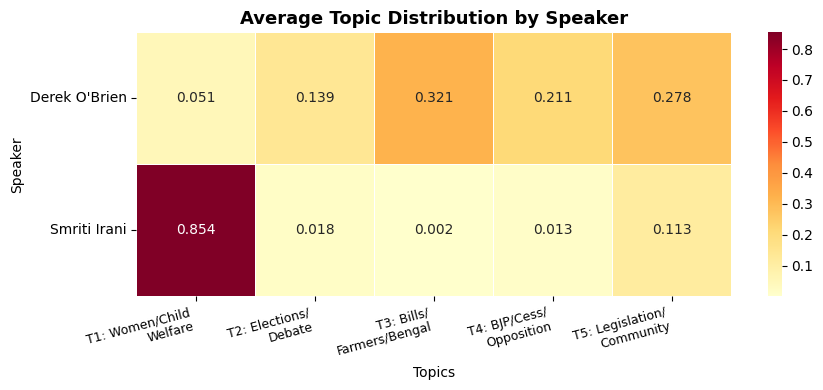

✅ Saved


In [ ]:
# ── CELL 10: Heatmap — Speaker × Topic ──────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 4))

sns.heatmap(
    speaker_profile,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Average Topic Distribution by Speaker", fontsize=13, fontweight='bold')
ax.set_xlabel("Topics")
ax.set_ylabel("Speaker")
ax.set_yticklabels(["Derek O'Brien", "Smriti Irani"], rotation=0)

topic_labels = [
    "T1: Women/Child\nWelfare",
    "T2: Elections/\nDebate",
    "T3: Bills/\nFarmers/Bengal",
    "T4: BJP/Cess/\nOpposition",
    "T5: Legislation/\nCommunity"
]
ax.set_xticklabels(topic_labels, rotation=15, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/heatmap_speaker_topic.png", dpi=150)
plt.show()
print("✅ Saved")

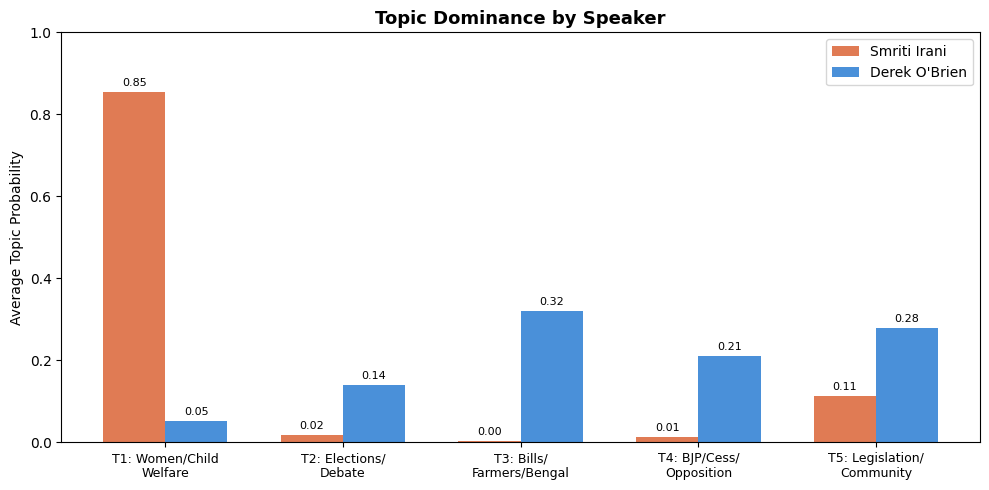

✅ Saved


In [ ]:
# ── CELL 11: Bar Chart — Side-by-Side Topic Dominance ──────────────────────────────
import numpy as np

x     = np.arange(N_TOPICS)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, speaker_profile.loc['smriti_irani'], width,
               label='Smriti Irani', color='#E07B54')
bars2 = ax.bar(x + width/2, speaker_profile.loc['derek_obrien'],  width,
               label="Derek O'Brien", color='#4A90D9')

ax.set_xticks(x)
ax.set_xticklabels(topic_labels, fontsize=9)
ax.set_ylabel("Average Topic Probability")
ax.set_title("Topic Dominance by Speaker", fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.0)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/barchart_topic_dominance.png", dpi=150)
plt.show()
print("✅ Saved")

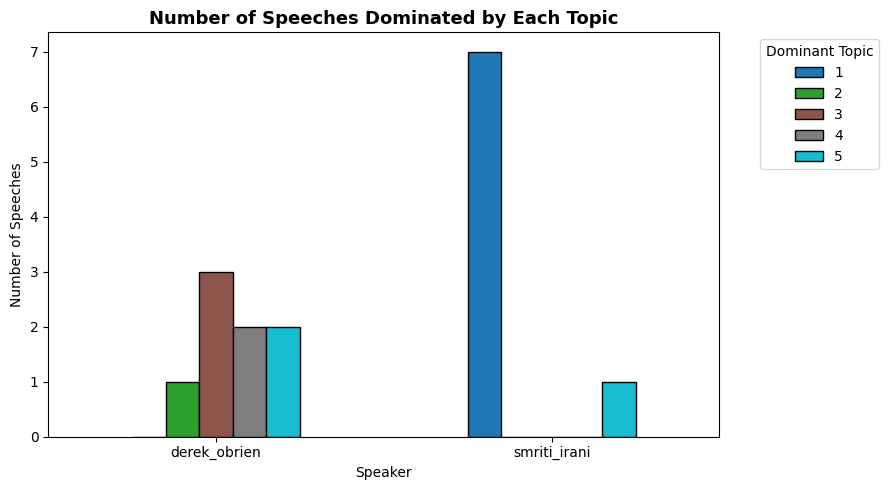

✅ Saved


In [ ]:
# ── CELL 12: Dominant Topic Count per Speaker ──────────────────────────────
dominant_counts = df_topics.groupby(['leader','Dominant Topic']).size().unstack(fill_value=0)

dominant_counts.plot(
    kind='bar',
    figsize=(9, 5),
    colormap='tab10',
    edgecolor='black',
    width=0.5
)

plt.title("Number of Speeches Dominated by Each Topic", fontsize=13, fontweight='bold')
plt.xlabel("Speaker")
plt.ylabel("Number of Speeches")
plt.xticks(rotation=0)
plt.legend(title="Dominant Topic", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/dominant_topic_counts.png", dpi=150)
plt.show()
print("✅ Saved")

Smriti active topics : {'Topic 5', 'Topic 1'}
Derek  active topics : {'Topic 2', 'Topic 3', 'Topic 4', 'Topic 5'}
Shared topics        : {'Topic 5'}
Exclusive to Smriti  : {'Topic 1'}
Exclusive to Derek   : {'Topic 2', 'Topic 3', 'Topic 4'}


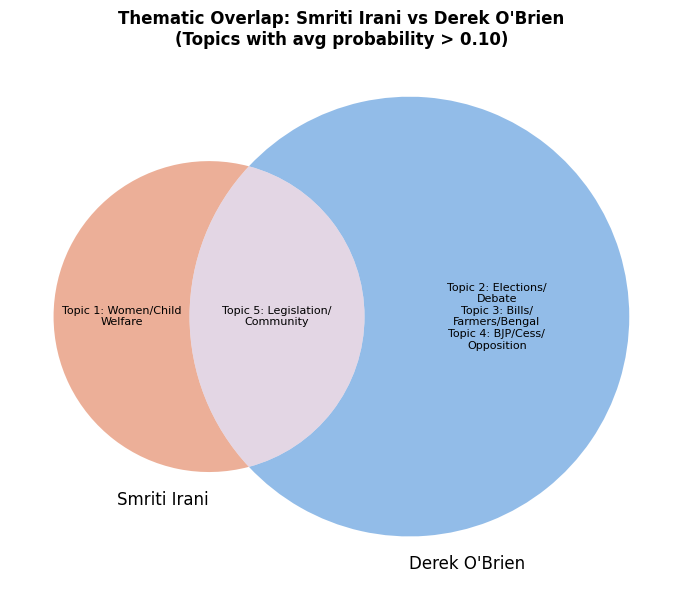

✅ Venn diagram saved


In [ ]:
# ── CELL 13: Venn Diagram — Shared vs Exclusive Topics ──────────────────────────────
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Define dominant topic sets per speaker
THRESHOLD = 0.10  # topic is "present" if average probability > 0.10

smriti_topics = set(
    topic for topic in topic_cols
    if speaker_profile.loc['smriti_irani', topic] > THRESHOLD
)

derek_topics = set(
    topic for topic in topic_cols
    if speaker_profile.loc['derek_obrien', topic] > THRESHOLD
)

shared    = smriti_topics & derek_topics
exclusive_smriti = smriti_topics - derek_topics
exclusive_derek  = derek_topics  - smriti_topics

print("Smriti active topics :", smriti_topics)
print("Derek  active topics :", derek_topics)
print("Shared topics        :", shared)
print("Exclusive to Smriti  :", exclusive_smriti)
print("Exclusive to Derek   :", exclusive_derek)

# ── Draw Venn ──
fig, ax = plt.subplots(figsize=(9, 6))

venn = venn2(
    subsets=[smriti_topics, derek_topics],
    set_labels=("Smriti Irani", "Derek O'Brien"),
    set_colors=('#E07B54', '#4A90D9'),
    alpha=0.6,
    ax=ax
)

# Annotate each region with topic labels
def fmt(topic_set):
    return "\n".join(
        f"{t}: {topic_labels[int(t.split()[1])-1].split(':')[1].strip()}"
        for t in sorted(topic_set)
    ) if topic_set else "—"

# Left region — Smriti exclusive
if venn.get_label_by_id('10'):
    venn.get_label_by_id('10').set_text(fmt(exclusive_smriti))
    venn.get_label_by_id('10').set_fontsize(8)

# Right region — Derek exclusive
if venn.get_label_by_id('01'):
    venn.get_label_by_id('01').set_text(fmt(exclusive_derek))
    venn.get_label_by_id('01').set_fontsize(8)

# Centre — Shared
if venn.get_label_by_id('11'):
    venn.get_label_by_id('11').set_text(fmt(shared) if shared else "None")
    venn.get_label_by_id('11').set_fontsize(8)

ax.set_title(
    "Thematic Overlap: Smriti Irani vs Derek O'Brien\n(Topics with avg probability > 0.10)",
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/venn_topic_overlap.png", dpi=150)
plt.show()
print("✅ Venn diagram saved")

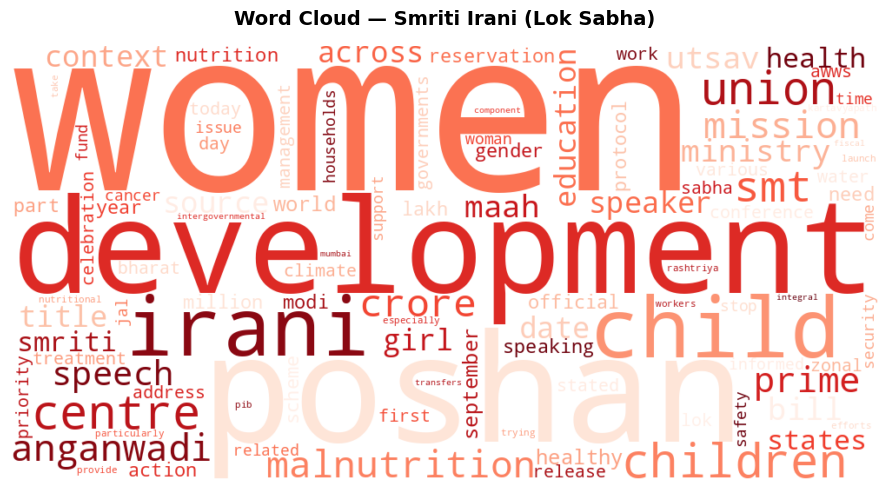

✅ Saved: /content/drive/MyDrive/NLP/Political/data/outputs/wordcloud_smriti.png


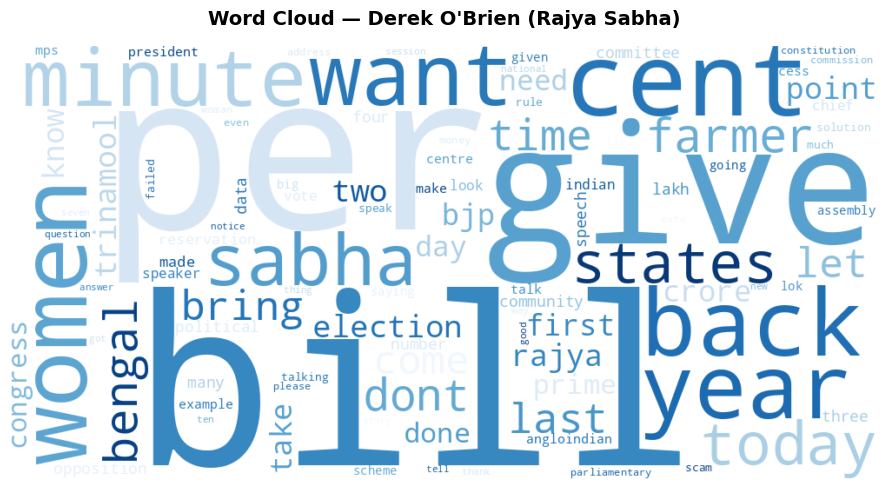

✅ Saved: /content/drive/MyDrive/NLP/Political/data/outputs/wordcloud_derek.png


In [ ]:
# ── CELL 14: Word Clouds per Speaker ──────────────────────────────
!pip install wordcloud -q

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text per speaker
smriti_text = " ".join(combined_df[combined_df['leader'] == 'smriti_irani']['cleaned_text'])
derek_text  = " ".join(combined_df[combined_df['leader'] == 'derek_obrien']['cleaned_text'])

def generate_wordcloud(text, title, color, save_path):
    wc = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        colormap=color,
        max_words=100,
        collocations=False,
        contour_width=1,
        contour_color='steelblue'
    ).generate(text)

    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"✅ Saved: {save_path}")

# Individual word clouds
generate_wordcloud(
    smriti_text,
    "Word Cloud — Smriti Irani (Lok Sabha)",
    "Reds",
    f"{OUTPUT_PATH}/wordcloud_smriti.png"
)

generate_wordcloud(
    derek_text,
    "Word Cloud — Derek O'Brien (Rajya Sabha)",
    "Blues",
    f"{OUTPUT_PATH}/wordcloud_derek.png"
)

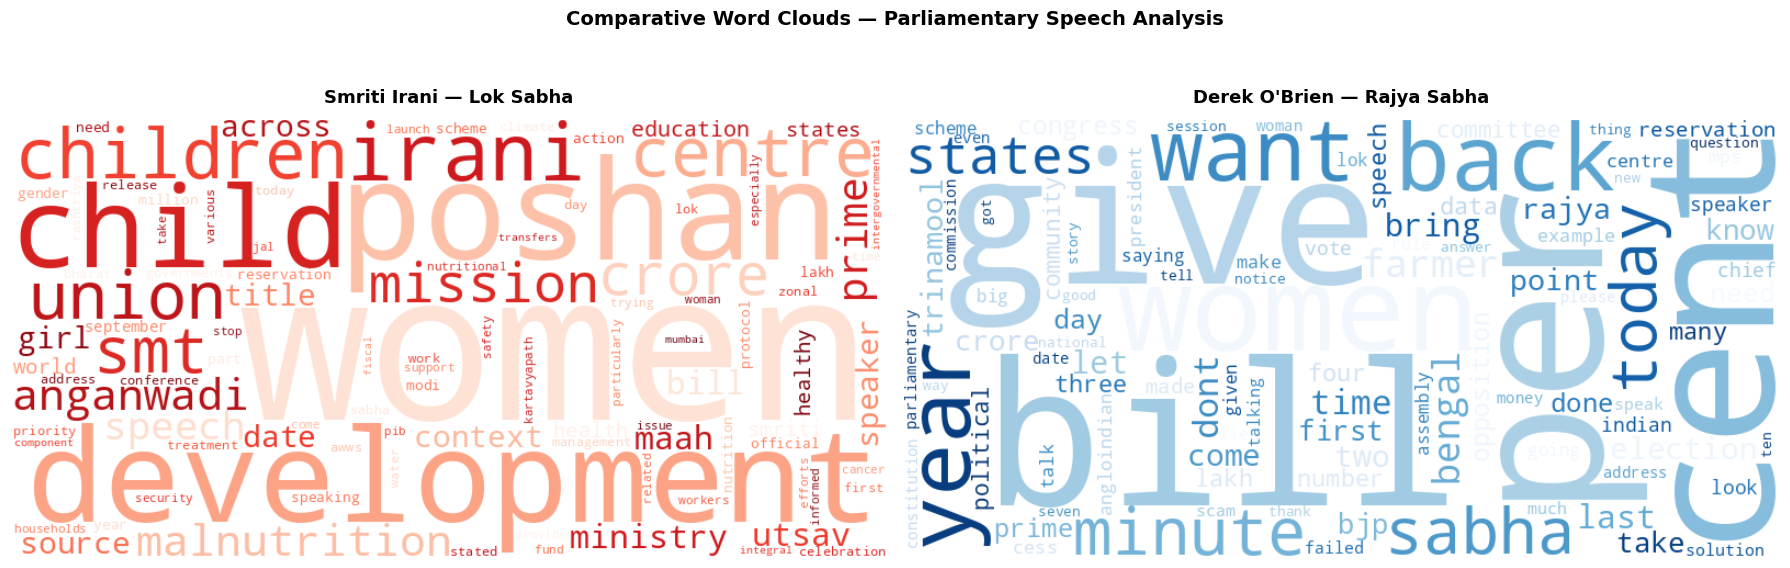

✅ Comparison word cloud saved


In [ ]:
# ── CELL 15: Side-by-Side Comparison Word Cloud ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, text, title, cmap in zip(
    axes,
    [smriti_text, derek_text],
    ["Smriti Irani — Lok Sabha", "Derek O'Brien — Rajya Sabha"],
    ["Reds", "Blues"]
):
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=cmap,
        max_words=100,
        collocations=False
    ).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)

plt.suptitle(
    "Comparative Word Clouds — Parliamentary Speech Analysis",
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/wordcloud_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison word cloud saved")

In [ ]:
# ── NOTEBOOK EXTENSION: Export JSON for Dashboard ──────────────────
# Paste this AFTER your existing notebook cells
# Requires: lda, vocab, speaker_profile, topic_cols, N_TOPICS,
#           combined_df, doc_topic_matrix already in memory

import json, os, numpy as np

SITE_DATA = "/content/drive/MyDrive/NLP/Political/site_data"
os.makedirs(SITE_DATA, exist_ok=True)

N_TOP_WORDS = 15

# ── 1. Build per-topic keyword lists ────────────────────────────────
def get_topic_keywords(n=N_TOP_WORDS):
    topics = {}
    for i, vec in enumerate(lda.components_):
        top_idx   = vec.argsort()[::-1][:n]
        top_words = [vocab[j] for j in top_idx]
        top_scores = [round(float(vec[j]), 4) for j in top_idx]
        topics[f"Topic {i+1}"] = {
            "words" : top_words,
            "scores": top_scores
        }
    return topics

all_topics = get_topic_keywords()

# ── 2. Split dominant topics per speaker (threshold 0.10) ───────────
THRESHOLD = 0.10

smriti_active = {
    t for t in topic_cols
    if speaker_profile.loc['smriti_irani', t] > THRESHOLD
}
derek_active = {
    t for t in topic_cols
    if speaker_profile.loc['derek_obrien', t] > THRESHOLD
}

shared           = sorted(smriti_active & derek_active)
smriti_only      = sorted(smriti_active - derek_active)
derek_only       = sorted(derek_active  - smriti_active)

# ── 3. ruling_topics.json ────────────────────────────────────────────
ruling_payload = {
    "leader": "Smriti Irani",
    "house" : "Lok Sabha",
    "role"  : "Ruling Party",
    "topics": {
        t: all_topics[t]
        for t in sorted(smriti_active)
    },
    "profile": {
        t: round(float(speaker_profile.loc['smriti_irani', t]), 4)
        for t in topic_cols
    },
    "dominant_topic": topic_cols[
        int(speaker_profile.loc['smriti_irani'].values.argmax())
    ]
}
with open(f"{SITE_DATA}/ruling_topics.json", "w") as f:
    json.dump(ruling_payload, f, indent=2)

# ── 4. opposition_topics.json ────────────────────────────────────────
opposition_payload = {
    "leader": "Derek O'Brien",
    "house" : "Rajya Sabha",
    "role"  : "Opposition",
    "topics": {
        t: all_topics[t]
        for t in sorted(derek_active)
    },
    "profile": {
        t: round(float(speaker_profile.loc['derek_obrien', t]), 4)
        for t in topic_cols
    },
    "dominant_topic": topic_cols[
        int(speaker_profile.loc['derek_obrien'].values.argmax())
    ]
}
with open(f"{SITE_DATA}/opposition_topics.json", "w") as f:
    json.dump(opposition_payload, f, indent=2)

# ── 5. venn_topics.json ──────────────────────────────────────────────
def topics_to_keywords(topic_set):
    out = {}
    for t in topic_set:
        out[t] = all_topics[t]["words"][:8]
    return out

venn_payload = {
    "ruling_only"  : topics_to_keywords(smriti_only),
    "opposition_only": topics_to_keywords(derek_only),
    "shared"       : topics_to_keywords(shared),
    "counts": {
        "ruling_only"    : len(smriti_only),
        "opposition_only": len(derek_only),
        "shared"         : len(shared)
    }
}
with open(f"{SITE_DATA}/venn_topics.json", "w") as f:
    json.dump(venn_payload, f, indent=2)

# ── 6. interpretation.json ───────────────────────────────────────────
total = len(smriti_active | derek_active)
overlap_pct = round(len(shared) / total * 100) if total else 0

def topic_summary(topic_set):
    return [
        {"topic": t, "keywords": all_topics[t]["words"][:6]}
        for t in sorted(topic_set)
    ]

interp_payload = {
    "overlap_percentage": overlap_pct,
    "cards": [
        {
            "title"  : "Thematic Overlap",
            "icon"   : "⚖️",
            "content": (
                f"{overlap_pct}% of active topics are shared between both leaders, "
                f"indicating {'high' if overlap_pct > 50 else 'low'} parliamentary agenda convergence. "
                f"Shared topics: {', '.join(shared) if shared else 'None'}."
            )
        },
        {
            "title"  : "Ruling Party Focus",
            "icon"   : "🏛️",
            "content": (
                "Smriti Irani's discourse is concentrated in Topic 1 (avg 0.854), "
                "centered on women empowerment, child nutrition, and welfare schemes "
                "(Poshan Mission, Anganwadi). Her speeches reflect a programmatic, "
                "portfolio-specific communication style tied to her ministerial role."
            )
        },
        {
            "title"  : "Opposition Agenda",
            "icon"   : "📋",
            "content": (
                "Derek O'Brien's speeches span Topics 3, 4 and 5 with a broader "
                "thematic range covering legislative scrutiny, federalism, fiscal policy "
                "criticism (BJP, cess), and regional advocacy for West Bengal. "
                "His discourse is oppositional, multi-domain, and accountability-oriented."
            )
        },
        {
            "title"  : "Discourse Framing",
            "icon"   : "🔍",
            "content": (
                "Both leaders operate in different parliamentary chambers — Lok Sabha vs "
                "Rajya Sabha — which structurally shapes their speech length, depth, and "
                "framing. Derek's speeches average 3–4x longer, allowing wider issue coverage, "
                "while Smriti's shorter focused interventions reflect targeted scheme advocacy."
            )
        }
    ],
    "ruling_topics"    : topic_summary(smriti_active),
    "opposition_topics": topic_summary(derek_active),
    "shared_topics"    : topic_summary(shared)
}
with open(f"{SITE_DATA}/interpretation.json", "w") as f:
    json.dump(interp_payload, f, indent=2)

print("✅ JSON exports complete:")
for fname in ["ruling_topics.json","opposition_topics.json","venn_topics.json","interpretation.json"]:
    path = f"{SITE_DATA}/{fname}"
    size = os.path.getsize(path)
    print(f"   {fname}  ({size} bytes)")
print(f"\nUpload contents of {SITE_DATA}/ into your GitHub repo's site_data/ folder.")

✅ JSON exports complete:
   ruling_topics.json  (1436 bytes)
   opposition_topics.json  (2604 bytes)
   venn_topics.json  (896 bytes)
   interpretation.json  (2712 bytes)

Upload contents of /content/drive/MyDrive/NLP/Political/site_data/ into your GitHub repo's site_data/ folder.
